# CLUSTERING PRODUCTOS

In [6]:
import pandas as pd
import plotly.express as px
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import HDBSCAN
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/data_dsmarket/'
except ImportError:
    DATA_PATH = 'data_dsmarket/'


df = pd.read_feather(DATA_PATH + 'df_preprocessed.feather')

In [4]:
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df.head()

,id,item,category,department,store,store_code,region,d,sales,weekday,...,yearweek,sell_price,season,pay_period,ingresos,is_holiday,year,week,month,indice_estacional_store_item
date,,,,,,,,,,,,,,,,,,,,,
2011-01-29,ACCESORIES_1_008_NYC_1,ACCESORIES_1_008,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,12,Saturday,...,201105,0.6118,Invierno,otros,7.3416,0,2011,5,1,2.058577
2011-01-29,ACCESORIES_1_009_NYC_1,ACCESORIES_1_009,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,2,Saturday,...,201105,2.0748,Invierno,otros,4.1496,0,2011,5,1,0.726826
2011-01-29,ACCESORIES_1_010_NYC_1,ACCESORIES_1_010,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,Saturday,...,201105,4.2161,Invierno,otros,0.0000,0,2011,5,1,1.775047
2011-01-29,ACCESORIES_1_012_NYC_1,ACCESORIES_1_012,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,Saturday,...,201105,7.9534,Invierno,otros,0.0000,0,2011,5,1,1.068961
2011-01-29,ACCESORIES_1_015_NYC_1,ACCESORIES_1_015,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,4,Saturday,...,201105,0.9310,Invierno,otros,3.7240,0,2011,5,1,1.779883


## ANÁLISIS ABC/XYZ

In [7]:
datos = df.reset_index()
# calculamos las ventas totales por artículo
abc = datos.groupby('item')['sales'].sum().reset_index(name='total_sales')
# calculamos el porcentaje que representa cada artículo sobre el total de ventas
abc['porcentaje_total'] = abc['total_sales'] / abc['total_sales'].sum()
# ordenamos por el porcentje
abc = abc.sort_values('porcentaje_total', ascending=False).reset_index(drop=True)
# ahora calculamos el porcentaje acumulado porque así por ejemplo vemos que los items 1, 2 y 3 representan el 80% de las ventas, el 4 y 5 el siguiente 15% y el resto el 5% restante (x ej para entenderlo)
abc['porcentaje_acumulado'] = abc['porcentaje_total'].cumsum()

# ahora para la clasificacion XYZ tenemos que mirar como de estable o variable es la demanda de los productos. Calculamos la media de las ventas, la desv estandar y el coeficiente de variación (std/mean) para cada artículo. 
# agregamos por semana (creo que es mejor, preguntar a dani) porque si lo hacemos por dia igual hay mucho ruido, y lo que queremos es ver la tendencia general de cada producto
weekly = (datos.groupby(['item', pd.Grouper(key='date', freq='W')])['sales'].sum().reset_index()) # el pd.Grouper es para agrupar por semana, tambien lo podriamos haber hecho agrupando por yearweek creo 
# creamos la media y la desviacion 
xyz = weekly.groupby('item')['sales'].agg(['mean', 'std']).reset_index()
# rellenamos los valores nulos de std con 0 (esto pasa cuando un producto solo se ha vendido una semana, entonces la desviacion es 0)
xyz['std'] = xyz['std'].fillna(0)
# calculamos el coeficiente de variacion
xyz['cv'] = np.where(xyz['mean'] > 0, xyz['std'] / xyz['mean'], np.nan)
# vamos a crear dos funciones para clasificar en ABC y XYZ
def clasificar_xyz(cv):
    if pd.isna(cv):
        return "Z"
    elif cv <= 0.5:
        return "X"
    elif cv <= 1.0:
        return "Y"
    else:
        return "Z"
    
def clasificar_abc(p):
    if p <= 0.80:
        return "A"
    elif p <= 0.95:
        return "B"
    else:
        return "C"

abc['ABC'] = abc['porcentaje_acumulado'].apply(clasificar_abc)
xyz['XYZ'] = xyz['cv'].apply(clasificar_xyz)   
# ahora unimos ambos dataframes para tener la clasificacion ABC y XYZ en el mismo dataframe
clasificacion = abc.merge(xyz[['item', 'mean', 'std', 'cv', 'XYZ']], on='item', how='left')
# creamos una nueva columna que combine ambas clasificaciones
clasificacion['segmento'] = clasificacion['ABC'] + clasificacion['XYZ']


In [8]:
clasificacion

,item,total_sales,porcentaje_total,porcentaje_acumulado,ABC,mean,std,cv,XYZ,segmento
0,SUPERMARKET_3_090,1002529,0.015260,0.015260,A,3658.864964,2347.509055,0.641595,Y,AY
1,SUPERMARKET_3_586,920242,0.014008,0.029268,A,3358.547445,519.597935,0.154709,X,AX
2,SUPERMARKET_3_252,565299,0.008605,0.037873,A,2063.135036,416.353559,0.201806,X,AX
3,SUPERMARKET_3_555,491287,0.007478,0.045351,A,1793.018248,369.668453,0.206171,X,AX
4,SUPERMARKET_3_714,396172,0.006030,0.051382,A,1445.883212,319.309192,0.220840,X,AX
...,...,...,...,...,...,...,...,...,...,...
3044,HOME_&_GARDEN_2_005,757,0.000012,0.999959,C,2.762774,3.719851,1.346419,Z,CZ
3045,ACCESORIES_2_084,746,0.000011,0.999970,C,2.722628,4.252523,1.561919,Z,CZ
3046,HOME_&_GARDEN_2_175,718,0.000011,0.999981,C,2.620438,4.566371,1.742598,Z,CZ
3047,ACCESORIES_2_119,660,0.000010,0.999991,C,2.408759,1.936935,0.804122,Y,CY


In [9]:
ventas_segmentos = (clasificacion.groupby("segmento", as_index=False)["total_sales"].sum().sort_values("total_sales", ascending=False))

ventas_segmentos["pct_sales"] = 100 * ventas_segmentos["total_sales"] / ventas_segmentos["total_sales"].sum()
print(ventas_segmentos)
# hemos creado un dataset para ver el porcentaje de ventas que representa cada segmento, y así entender mejor la importancia de cada uno. 

  segmento  total_sales  pct_sales
0       AX     27167207  41.353281
1       AY     22465961  34.197155
4       BY      4147395   6.313067
3       BX      3684837   5.608972
2       AZ      2911722   4.432154
5       BZ      2028456   3.087668
8       CZ      1429510   2.175966
7       CY      1237686   1.883976
6       CX       622635   0.947760


In [10]:
for seg in ["AX", "AY", "AZ", "BX", "BY", "BZ", "CX", "CY", "CZ"]:
    print(f"\n--- {seg} ---")
    print(clasificacion.loc[clasificacion["segmento"] == seg, ["item", "total_sales", "mean", "std", "cv"]].sort_values("total_sales", ascending=False) .head(10))


--- AX ---
                 item  total_sales         mean         std        cv
1   SUPERMARKET_3_586       920242  3358.547445  519.597935  0.154709
2   SUPERMARKET_3_252       565299  2063.135036  416.353559  0.201806
3   SUPERMARKET_3_555       491287  1793.018248  369.668453  0.206171
4   SUPERMARKET_3_714       396172  1445.883212  319.309192  0.220840
5   SUPERMARKET_3_587       396119  1445.689781  677.484138  0.468623
6   SUPERMARKET_3_694       390001  1423.361314  200.859137  0.141116
7   SUPERMARKET_3_226       363082  1325.116788  202.065219  0.152489
8   SUPERMARKET_3_202       295689  1079.156934  407.915196  0.377994
13  SUPERMARKET_3_377       273289   997.405109  126.314133  0.126643
15  SUPERMARKET_3_080       262650   958.576642  184.672891  0.192653

--- AY ---
                 item  total_sales         mean          std        cv
0   SUPERMARKET_3_090      1002529  3658.864964  2347.509055  0.641595
9   SUPERMARKET_3_723       284333  1037.711679   637.831693  0.

In [11]:
product_info = df[["item", "category", "department"]].drop_duplicates()
segmentacion = clasificacion.merge(product_info, on="item", how="left")
pd.crosstab(segmentacion["segmento"], segmentacion["category"])

category,ACCESORIES,HOME_&_GARDEN,SUPERMARKET
segmento,,,
AX,61,133,295
AY,20,99,340
AZ,6,17,62
BX,92,144,122
BY,58,140,221
BZ,15,65,133
CX,51,93,13
CY,144,164,63
CZ,118,192,188


In [12]:
tabla_pct = pd.crosstab(
    segmentacion["segmento"],
    segmentacion["category"],
    normalize="index"
)

fig = px.imshow(
    tabla_pct,
    text_auto=".2f",
    color_continuous_scale="Blues",
    aspect="auto"
)

fig.update_layout(
    title="Proporción de categorías dentro de cada segmento",
    xaxis_title="Categoría",
    yaxis_title="Segmento ABC-XYZ"
)

fig.show()

In [13]:
ventas_seg_cat = (
    segmentacion.groupby(["segmento", "category"])["total_sales"]
    .sum()
    .reset_index()
)

tabla_ventas = ventas_seg_cat.pivot(
    index="segmento",
    columns="category",
    values="total_sales"
).fillna(0)

tabla_ventas_pct = tabla_ventas.div(tabla_ventas.sum(axis=1), axis=0)

fig = px.imshow(
    tabla_ventas_pct,
    text_auto=".2f",
    color_continuous_scale="Blues",
    aspect="auto"
)

fig.update_layout(
    title="Distribución de ventas por categoría dentro de cada segmento",
    xaxis_title="Categoría",
    yaxis_title="Segmento ABC-XYZ"
)

fig.update_traces(
    hovertemplate="Segmento: %{y}<br>Categoría: %{x}<br>% Ventas: %{z:.2f}<extra></extra>"
)

fig.show()

In [14]:
clasificacion[["item", "segmento"]].to_csv(DATA_PATH + "etiquetas_productos_abcxyz.csv", index=False)

## CLUSTERING

### FEATURE ENGINEERING

Vamos a crear un nuevo dataframe con la información de cada producto, creando variables que nos puedan servir para hacer las agrupaciones

In [15]:
# para cada region separamos los datos, creamos una nueva columna 'quarter' que indica el trimestre del año, y luego usamos pd.crosstab para calcular la suma de las ventas totales por artículo y trimestre.
# Finalmente, renombramos las columnas para que sean más descriptivas y restablecemos el índice para que 'item' vuelva a ser una columna normal.
regions = df['region'].unique()
dfs = []
for region in regions:
    df_region = df[df['region'] == region].copy()
    df_region['quarter'] = df_region.index.quarter
    df_region = pd.crosstab(df_region['item'], df_region['quarter'], values=df_region['ingresos'], aggfunc='sum', normalize='index')
    df_region.columns = [f'{region}_Trimestre{col}' for col in df_region.columns]
    df_region.reset_index(inplace=True)
    dfs.append(df_region)


In [16]:
# unimos los 3 dataframes resultantes en uno solo usando pd.merge, asegurándonos de mantener la columna 'item' como clave de unión. Luego, calculamos el total de unidades vendidas por 'item' y el precio medio total por 'item', y realizamos merges adicionales para agregar esta información al dataframe final.
df_merge = pd.merge(dfs[0], dfs[1], on='item', how='outer')
df_merge = pd.merge(df_merge, dfs[2], on='item', how='outer')

In [17]:
numero_uds_vendidas= df.groupby('item')['sales'].sum().reset_index(name='unidades vendidas')
precio_medio_articulo = df.groupby('item')['sell_price'].mean().reset_index(name='precio medio total')
df_merge = pd.merge(df_merge, numero_uds_vendidas, on='item', how='left')
df_final= pd.merge(df_merge, precio_medio_articulo, on='item', how='left')
df_final.head()

,item,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4,Philadelphia_Trimestre1,Philadelphia_Trimestre2,Philadelphia_Trimestre3,Philadelphia_Trimestre4,unidades vendidas,precio medio total
0,ACCESORIES_1_001,0.292514,0.182852,0.230936,0.293697,0.261407,0.208852,0.229902,0.299840,0.287250,0.192133,0.246951,0.273666,4093,11.032746
1,ACCESORIES_1_002,0.175182,0.190535,0.264493,0.369789,0.205070,0.241527,0.260608,0.292795,0.218956,0.177950,0.248356,0.354739,5059,5.276608
2,ACCESORIES_1_003,0.292750,0.247606,0.187415,0.272230,0.266449,0.247798,0.285917,0.199837,0.331651,0.256824,0.221132,0.190392,1435,3.943978
3,ACCESORIES_1_004,0.270005,0.255676,0.228044,0.246275,0.262313,0.260763,0.231879,0.245044,0.289951,0.262349,0.219520,0.228180,39175,5.982920
4,ACCESORIES_1_005,0.242563,0.202705,0.268171,0.286560,0.212692,0.220332,0.266664,0.300312,0.266457,0.193219,0.214482,0.325841,14621,3.833668


In [18]:
# añadimos las ventas por trimestre en general para cada artículo, sin segmentar por región, y luego calculamos el precio medio total por artículo. Finalmente, realizamos merges adicionales para agregar esta información al dataframe final.
ventas_trimestre = (df.groupby(['item', df.index.quarter.rename('quarter')])['sales'].sum().unstack('quarter').rename(columns={1: 'Q1_total', 2: 'Q2_total', 3: 'Q3_total', 4: 'Q4_total'}).reset_index())
q_cols = ['Q1_total', 'Q2_total', 'Q3_total', 'Q4_total']
ventas_trimestre[q_cols] = ventas_trimestre[q_cols].div( ventas_trimestre[q_cols].sum(axis=1), axis=0)
df_final = pd.merge(df_final, ventas_trimestre, on='item', how='left')

In [19]:
ventas_findes = df[df.index.weekday >= 5].groupby('item')['sales'].sum().reset_index(name='ventas_fines_semana')
# ventas_findes
ventas_total = df.groupby('item')['sales'].sum().reset_index(name='ventas_total')
porcentaje_findes = pd.merge(ventas_findes, ventas_total, on='item', how='left')
# porcentaje_findes
porcentaje_findes['porcentaje_findes'] = porcentaje_findes['ventas_fines_semana'] / porcentaje_findes['ventas_total']

In [20]:
ventas_festivos = df[df['is_holiday']== True].groupby('item')['sales'].sum().reset_index(name='ventas_festivos')
# ventas_festivos
ventas_total = df.groupby('item')['sales'].sum().reset_index(name='ventas_total')
porcentaje_festivos = pd.merge(ventas_festivos, ventas_total, on='item', how='left')
porcentaje_festivos['porcentaje_festivos'] = porcentaje_festivos['ventas_festivos'] / porcentaje_festivos['ventas_total']

In [21]:
df_final = pd.merge(df_final, porcentaje_findes[['item', 'porcentaje_findes']], on='item', how='left')
df_final = pd.merge(df_final, porcentaje_festivos[['item', 'porcentaje_festivos']], on='item', how='left')

In [22]:
ventas_region = df.groupby(['item', 'region'])['ingresos'].sum().reset_index()
ventas_region['ingresos_norm'] = ventas_region.groupby('item')['ingresos'].transform(lambda x: x / x.sum())
ventas_region_pivot = ventas_region.pivot(index='item', columns='region', values='ingresos_norm').reset_index()
ventas_region_pivot['regionalidad'] = ventas_region_pivot.iloc[:, 1:].max(axis=1) - ventas_region_pivot.iloc[:, 1:].min(axis=1)
regionalidad = ventas_region_pivot[['item', 'regionalidad']]

df_final = pd.merge(df_final, regionalidad, on='item', how='left')



Regionalidad baja (~0) → producto de distribución uniforme, se puede gestionar de forma centralizada


Regionalidad alta (~1) → producto muy local, tiene sentido gestionar su stock de forma independiente por región



El más bajo que se ve es 0.07 → producto que se vende casi igual en las 3 regiones

Los más altos rondan 0.49 → producto donde una región vende casi el doble que otra

In [24]:
# ahora vamos a incorporar la elasticidad de cada producto
resultados_elasticidad = []
for item in df['item'].dropna().unique(): # nos quedamos con cada producto e iteramos sobre ellos
    # print(item)
    # df_elasticidad = df[df['item'] == item].copy()
    # df_elasticidad = df_elasticidad[df_elasticidad['sales'] > 0]
    # df_elasticidad = df_elasticidad[df_elasticidad['sell_price'] > 0].copy()
    df_elasticidad = df[(df['item'] == item) & (df['sales'] > 0) & (df['sell_price'] > 0)].copy() # nos quedamos solo con las filas del producto que estemos analizando y que tengan ventas y precio mayor que 0, porque si no luego no podemos calcular el logaritmo
    if len(df_elasticidad) < 50: # si el producto tiene menos de 50 filas, no calculamos la elasticidad porque no tendriamos suficientes datos para que el modelo sea fiable
        continue
    if df_elasticidad['sell_price'].nunique() < 5: # si el producto tiene menos de 5 precios diferentes, no calculamos la elasticidad porque no tendriamos suficiente variabilidad en el precio para que el modelo sea fiable
        continue
    df_elasticidad['log_sales'] = np.log(df_elasticidad['sales']) # calcuamos el logaritmo de las ventas 
    df_elasticidad['log_price'] = np.log(df_elasticidad['sell_price']) # calculamos el logaritmo del precio
    model = smf.ols('log_sales ~ log_price + C(store) + C(week) + is_holiday', data=df_elasticidad).fit() # ajustamos un modelo de regresion lineal con log_sales como variable dependiente y log_price, store, week
    # con la c(store) y c(week) lo que hacemos es meter las tiendas y las semanas como variables categoricas para controlar por su efecto, y con is_holiday controlamos por si el dia es festivo o no, porque eso tambien puede afectar a las ventas.
    resultados_elasticidad.append({
        'item': item,
        'elasticidad_precio': model.params['log_price'], # la elasticidad precio es el coeficiente que acompaña a log_price en el modelo, porque eso nos indica cuanto cambia el logaritmo de las ventas cuando cambia el logaritmo del precio
        'pvalue': model.pvalues['log_price'], # el pvalue nos indica si el coeficiente es estadisticamente significativo o no, es decir, si podemos confiar en que esa elasticidad precio es real o si puede ser debida al azar
        'r2': model.rsquared, # el r2 nos indica cuanto de la variabilidad de las ventas se explica por el modelo, es decir, por el precio, la tienda, la semana y si es festivo o no
        # n o hemso metido el n obs
    })

elasticidad_item = pd.DataFrame(resultados_elasticidad)

In [25]:
elasticidad_item.sort_values('elasticidad_precio')

,item,elasticidad_precio,pvalue,r2
1189,HOME_&_GARDEN_1_078,-5.831409,1.292160e-21,0.101908
387,SUPERMARKET_1_096,-5.689513,0.000000e+00,0.632690
210,HOME_&_GARDEN_1_434,-5.370367,3.342331e-113,0.359840
1382,SUPERMARKET_2_117,-5.110993,2.858359e-31,0.253007
1067,SUPERMARKET_3_313,-5.036914,0.000000e+00,0.295531
...,...,...,...,...
1375,SUPERMARKET_3_236,4.548637,3.121399e-20,0.196611
214,HOME_&_GARDEN_1_440,5.770910,1.528775e-38,0.171032
347,HOME_&_GARDEN_2_465,6.878159,3.876164e-10,0.145597
1416,SUPERMARKET_3_233,10.607670,2.382015e-149,0.406476


In [ ]:
# elasticidad_item.to_feather(DATA_PATH + 'elasticidad_item.feather')

In [ ]:
# elasticidad_item = pd.read_feather(DATA_PATH + 'elasticidad_item.feather')

In [26]:
ventas_diarias = df.groupby(["item", "date"], as_index=False)["sales"].sum()
pct_dias = ventas_diarias.groupby("item")["sales"].apply(lambda x: (x > 0).mean()).reset_index(name="pct_dias_con_ventas")
display(pct_dias.sort_values("pct_dias_con_ventas"))
ventas = ventas_diarias.groupby("item")["sales"].agg(["mean", "std"]).reset_index().rename(columns={"mean": "media_ventas", "std": "desv_ventas"})
ventas['cv_ventas'] = ventas['desv_ventas'] / ventas['media_ventas']
display(ventas)

df_final = pd.merge(df_final, ventas, on='item', how='left')
df_final = pd.merge(df_final, pct_dias, on='item', how='left')

,item,pct_dias_con_ventas
2520,SUPERMARKET_3_296,0.100366
2787,SUPERMARKET_3_563,0.141662
2690,SUPERMARKET_3_466,0.143231
1311,HOME_&_GARDEN_2_216,0.148458
2228,SUPERMARKET_3_003,0.167277
...,...,...
2601,SUPERMARKET_3_377,0.998955
2476,SUPERMARKET_3_252,0.998955
2810,SUPERMARKET_3_586,0.999477
2779,SUPERMARKET_3_555,0.999477


,item,media_ventas,desv_ventas,cv_ventas
0,ACCESORIES_1_001,2.139571,2.669537,1.247697
1,ACCESORIES_1_002,2.644537,2.342339,0.885727
2,ACCESORIES_1_003,0.750131,1.431958,1.908945
3,ACCESORIES_1_004,20.478306,8.219827,0.401392
4,ACCESORIES_1_005,7.642969,4.997235,0.653834
...,...,...,...,...
3044,SUPERMARKET_3_823,8.043910,7.569079,0.940970
3045,SUPERMARKET_3_824,4.351803,3.945778,0.906699
3046,SUPERMARKET_3_825,7.070570,5.668191,0.801660
3047,SUPERMARKET_3_826,6.371145,6.471392,1.015735


In [27]:
df_final = pd.merge(df_final, elasticidad_item[['item', 'elasticidad_precio']], on='item', how='left')

In [ ]:
# df_final.to_feather(DATA_PATH + 'df_clustering_items.feather')

### ANÁLISIS EXPLORATORIO DE LAS VARIABLES 

In [ ]:
# df_final= pd.read_feather(DATA_PATH + 'df_clustering_items.feather')

In [28]:
df_final.head()

,item,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4,Philadelphia_Trimestre1,...,Q3_total,Q4_total,porcentaje_findes,porcentaje_festivos,regionalidad,media_ventas,desv_ventas,cv_ventas,pct_dias_con_ventas,elasticidad_precio
0,ACCESORIES_1_001,0.292514,0.182852,0.230936,0.293697,0.261407,0.208852,0.229902,0.299840,0.287250,...,0.232348,0.292939,0.332763,0.055949,0.493571,2.139571,2.669537,1.247697,0.508625,-1.222391
1,ACCESORIES_1_002,0.175182,0.190535,0.264493,0.369789,0.205070,0.241527,0.260608,0.292795,0.218956,...,0.255584,0.348686,0.351255,0.042301,0.337518,2.644537,2.342339,0.885727,0.846315,NaN
2,ACCESORIES_1_003,0.292750,0.247606,0.187415,0.272230,0.266449,0.247798,0.285917,0.199837,0.331651,...,0.221603,0.234146,0.379094,0.055749,0.283080,0.750131,1.431958,1.908945,0.312075,NaN
3,ACCESORIES_1_004,0.270005,0.255676,0.228044,0.246275,0.262313,0.260763,0.231879,0.245044,0.289951,...,0.228156,0.243063,0.359872,0.047096,0.416094,20.478306,8.219827,0.401392,0.993204,NaN
4,ACCESORIES_1_005,0.242563,0.202705,0.268171,0.286560,0.212692,0.220332,0.266664,0.300312,0.266457,...,0.253881,0.305793,0.359073,0.047466,0.315161,7.642969,4.997235,0.653834,0.922635,-0.720161


In [29]:
px.histogram(elasticidad_item, x='elasticidad_precio', nbins=40, title='Distribución de elasticidades por producto')

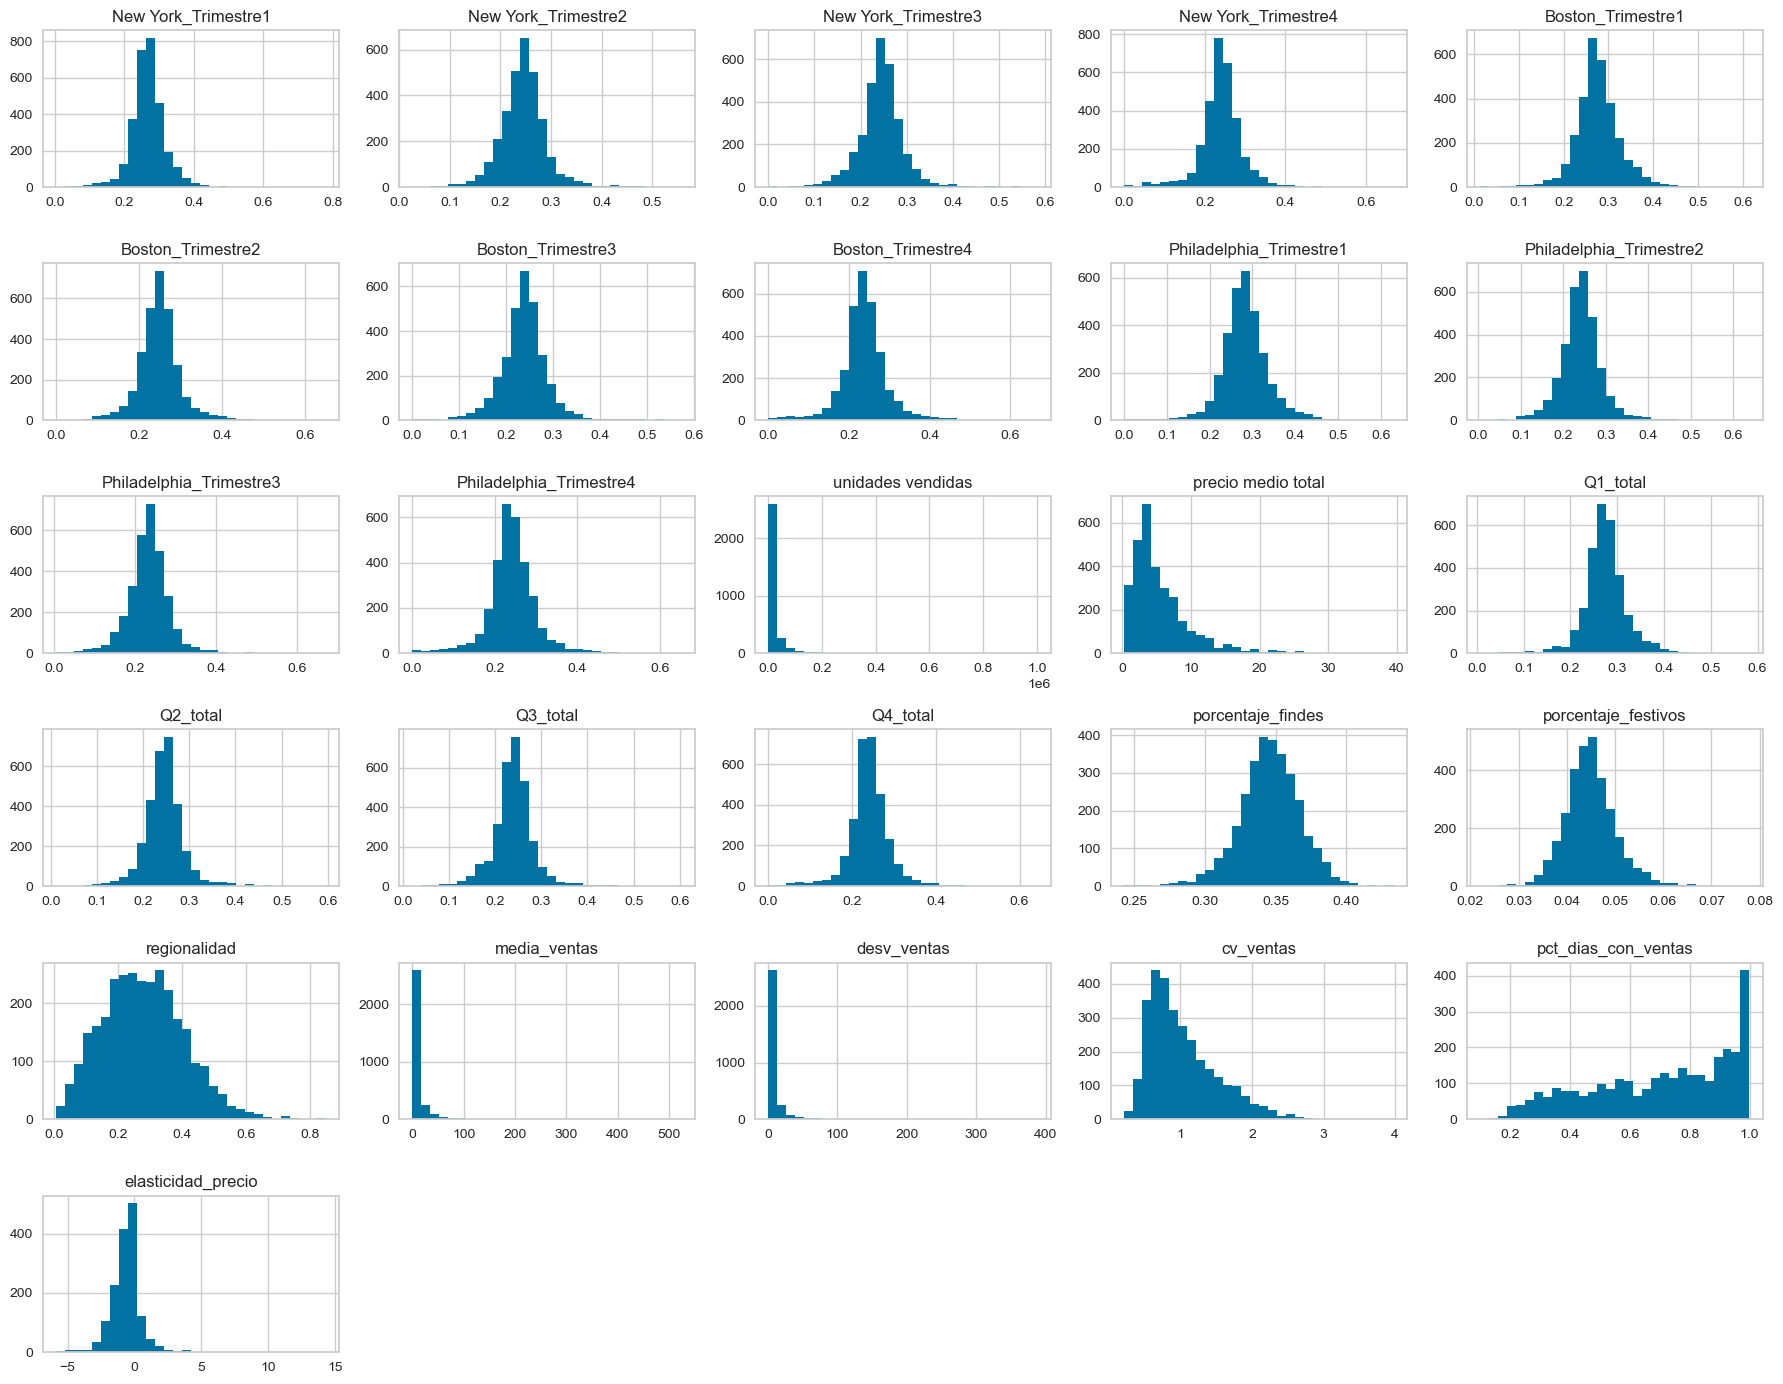

In [30]:
df_final.drop(columns=["item"]).hist(figsize=(18, 14), bins=30) # lo hago con matplotlib porque con plotly no me deja hacer tantos histogramas juntos, y con seaborn tampoco me quedaban bien, asi que al final lo hago con matplotlib que es lo mas sencillo para esto
plt.tight_layout()
plt.show()

In [31]:
# vamos a aplicar una transformacion logaritmica a las unidades vendidas y al percio medio total 
df_final["unidades vendidas"] = np.log1p(df_final["unidades vendidas"])
df_final["precio medio total"] = np.log1p(df_final["precio medio total"])

In [ ]:
px.histogram(df_final, x='unidades vendidas', nbins=40, title='Distribución de unidades vendidas (log transformada)')

In [ ]:
px.histogram(df_final, x='precio medio total', nbins=40, title='Distribución de precio medio total (log transformada)')

In [ ]:
# eliminamos media_ventas y desv_ventas
df_final = df_final.drop(columns=["media_ventas", "desv_ventas"])

In [ ]:
print(df_final.columns.tolist())

['item', 'New York_Trimestre1', 'New York_Trimestre2', 'New York_Trimestre3', 'New York_Trimestre4', 'Boston_Trimestre1', 'Boston_Trimestre2', 'Boston_Trimestre3', 'Boston_Trimestre4', 'Philadelphia_Trimestre1', 'Philadelphia_Trimestre2', 'Philadelphia_Trimestre3', 'Philadelphia_Trimestre4', 'unidades vendidas', 'precio medio total', 'Q1_total', 'Q2_total', 'Q3_total', 'Q4_total', 'porcentaje_findes', 'porcentaje_festivos', 'regionalidad', 'cv_ventas', 'pct_dias_con_ventas', 'elasticidad_precio']


In [ ]:
# vamos a ver las corerlacioens entre las variables 
corr = df_final.drop(columns=["item"]).corr(numeric_only=True)
# ahora con plotly e imshow para hacer un mapa de calor de las correlaciones
fig = px.imshow(corr, color_continuous_scale="RdBu_r", zmin=-1,zmax=1,aspect="auto",text_auto=".2f") # alo mejor es cosa mia pero viridis lo veo fatal 
fig.update_layout( width=1600, height=1000) # para q se vean todos lso nomrbes de las etiquetas
fig.show()


In [ ]:
df_q1 = df_final[['Boston_Trimestre1', 'New York_Trimestre1', 'Philadelphia_Trimestre1', 'Q1_total']]
corr = df_q1.corr(numeric_only=True)
# ahora con plotly e imshow para hacer un mapa de calor de las correlaciones
px.imshow(corr, text_auto=".2f", color_continuous_scale="RdBu_r", aspect="auto")

In [ ]:
df_q2 = df_final[['Boston_Trimestre2', 'New York_Trimestre2', 'Philadelphia_Trimestre2', 'Q2_total']]
corr = df_q2.corr(numeric_only=True)
# ahora con plotly e imshow para hacer un mapa de calor de las correlaciones
px.imshow(corr, text_auto=".2f", color_continuous_scale="RdBu_r", aspect="auto")

In [ ]:
df_q3 = df_final[['Boston_Trimestre3', 'New York_Trimestre3', 'Philadelphia_Trimestre3', 'Q3_total']]
corr = df_q3.corr(numeric_only=True)
# ahora con plotly e imshow para hacer un mapa de calor de las correlaciones
px.imshow(corr, text_auto=".2f", color_continuous_scale="RdBu_r", aspect="auto")

In [ ]:
# # INTENTO 1: eliminamos las variables de trimestres y nos quedamos con las desagregadas
# df_final = df_final.drop(columns=['Q1_total', 'Q2_total', 'Q3_total', 'Q4_total'])
# INTENTO 2: nos quedamos con las variables de trimestres totales y eliminamos las desagregadas por región
df_final = df_final.drop(columns=['Boston_Trimestre1', 'New York_Trimestre1', 'Philadelphia_Trimestre1', 'Boston_Trimestre2', 'New York_Trimestre2', 'Philadelphia_Trimestre2', 'Boston_Trimestre3', 'New York_Trimestre3', 'Philadelphia_Trimestre3', 'Boston_Trimestre4', 'New York_Trimestre4', 'Philadelphia_Trimestre4'])

In [ ]:
# ahroa escalamos las variables para que todas tengan la misma importancia a la hora de hacer el clustering. 
# Para eso usamos StandardScaler, que lo que hace es restar la media y dividir por la desviacion estandar, asi cada variable queda con media 0 y desviacion estandar 1.
scaler = StandardScaler()
variables_a_escalar = df_final.columns.drop('item') # escalamos todas las variables excepto la columna 'item' que es el identificador del producto
df_final_escalado = df_final.copy()
df_final_escalado[variables_a_escalar] = scaler.fit_transform(df_final_escalado[variables_a_escalar])

In [ ]:
df_final_escalado

,item,unidades vendidas,precio medio total,Q1_total,Q2_total,Q3_total,Q4_total,porcentaje_findes,porcentaje_festivos,regionalidad,cv_ventas,pct_dias_con_ventas,elasticidad_precio
0,ACCESORIES_1_001,-0.394473,1.204570,0.216354,-1.220124,-0.168138,0.997325,-0.585419,2.034643,1.676999,0.463476,-0.833529,-0.533828
1,ACCESORIES_1_002,-0.372640,-0.063918,-1.535133,-1.168100,0.332862,2.047029,0.260908,-0.482034,0.450469,-0.296040,0.613475,NaN
2,ACCESORIES_1_003,-0.454548,-0.357591,0.430249,0.097039,-0.399816,-0.109744,1.535021,1.997755,0.022605,1.850960,-1.675747,NaN
3,ACCESORIES_1_004,0.398427,0.091733,-0.066912,0.265378,-0.258527,0.058160,0.655294,0.402232,1.068048,-1.312312,1.242899,NaN
4,ACCESORIES_1_005,-0.156527,-0.381900,-0.757849,-0.980284,0.296150,1.239364,0.618689,0.470386,0.274745,-0.782617,0.940507,-0.113426
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,SUPERMARKET_3_823,-0.139191,-0.489183,0.351531,-1.114544,0.201253,0.466556,0.135649,0.034128,1.901986,-0.180125,0.118447,-0.541614
3045,SUPERMARKET_3_824,-0.298825,-0.559679,-0.941156,1.701117,0.419009,-0.992477,-0.597811,-1.238541,0.607481,-0.252034,0.268524,0.476573
3046,SUPERMARKET_3_825,-0.181275,-0.139339,0.663193,-0.108580,0.426863,-0.860193,0.111765,-0.007092,-0.695661,-0.472437,0.440999,0.223876
3047,SUPERMARKET_3_826,-0.211516,-0.888287,-0.635497,1.106719,0.078014,-0.455469,-1.752203,-0.959553,-0.366024,-0.023247,-0.524416,NaN


In [ ]:
df_final_escalado.isna().sum()
# tenemos que rellenar los valores nulos de la elasticidad de productos. 

item                      0
unidades vendidas         0
precio medio total        0
Q1_total                  0
Q2_total                  0
Q3_total                  0
Q4_total                  0
porcentaje_findes         0
porcentaje_festivos       0
regionalidad              0
cv_ventas                 0
pct_dias_con_ventas       0
elasticidad_precio     1528
dtype: int64

In [ ]:
df_final_escalado["elasticidad_precio"] = df_final_escalado["elasticidad_precio"].fillna(df_final_escalado["elasticidad_precio"].median())

### CREACIÓN DE LOS CLUSTERS

Lo primero que hemos hecho es probar con HDBSCAN, un método q no hemos visto en clase pero que parece una mejora del DBSCAN. Hemos probado varias combinaciones de configuraciones pero al entrar a analizar las agrupaciones concretamente, no nos han convencido.

#### HDBSCAN

In [ ]:
for mcs in [5, 8, 10, 15, 20]:
    for ms in [1, 3, 5, 8]:
        hdb = HDBSCAN(min_cluster_size = mcs, min_samples = ms, cluster_selection_method = "eom")
        labels = hdb.fit_predict(df_final_escalado.drop(columns = ["item"]))
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        print(f"min_cluster_size = {mcs}, min_samples = {ms} ---- clusters = {n_clusters}, ruido = {n_noise}")

min_cluster_size = 5, min_samples = 1 ---- clusters = 4, ruido = 94
min_cluster_size = 5, min_samples = 3 ---- clusters = 4, ruido = 110
min_cluster_size = 5, min_samples = 5 ---- clusters = 4, ruido = 152
min_cluster_size = 5, min_samples = 8 ---- clusters = 2, ruido = 2660
min_cluster_size = 8, min_samples = 1 ---- clusters = 3, ruido = 99
min_cluster_size = 8, min_samples = 3 ---- clusters = 3, ruido = 115
min_cluster_size = 8, min_samples = 5 ---- clusters = 2, ruido = 923
min_cluster_size = 8, min_samples = 8 ---- clusters = 0, ruido = 3049
min_cluster_size = 10, min_samples = 1 ---- clusters = 2, ruido = 52
min_cluster_size = 10, min_samples = 3 ---- clusters = 2, ruido = 67
min_cluster_size = 10, min_samples = 5 ---- clusters = 2, ruido = 923
min_cluster_size = 10, min_samples = 8 ---- clusters = 0, ruido = 3049
min_cluster_size = 15, min_samples = 1 ---- clusters = 3, ruido = 680
min_cluster_size = 15, min_samples = 3 ---- clusters = 3, ruido = 818
min_cluster_size = 15, min_sa

In [ ]:
hdb = HDBSCAN(min_cluster_size=5, min_samples=1,cluster_selection_method="eom")
labels_hdb = hdb.fit_predict(df_final_escalado.drop(columns=["item"]))

In [ ]:
pd.Series(labels_hdb).value_counts().sort_index()

-1      94
 0       5
 1      14
 2    2928
 3       8
dtype: int64

In [ ]:
2928/3049

# vemos que se agrupan el 96% de los productos en un mismo cluster, por eso no nos convencen los resultados

0.9603148573302722

#### KMEANS

In [ ]:
df_modificado = df_final_escalado.drop(columns =['porcentaje_findes', 'porcentaje_festivos', 'regionalidad', 'elasticidad_precio']) 

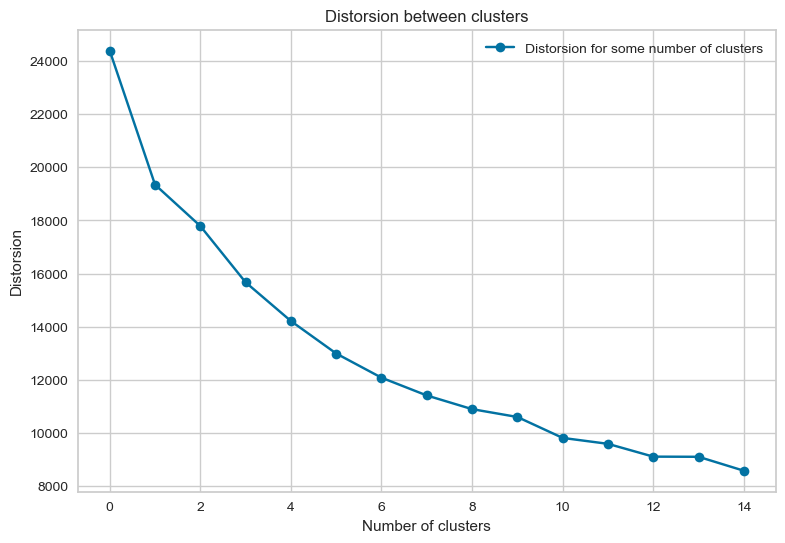

In [ ]:
cluster_distorsion = []
for i in range(1, 16):
    test_sklearn = KMeans(n_clusters=i)
    test_sklearn.fit(df_modificado.drop(columns=["item"]))
    cluster_distorsion.append(test_sklearn.inertia_)
plt.figure(figsize=(9, 6))
plt.plot(cluster_distorsion, marker='o', label='Distorsion for some number of clusters')
plt.title("Distorsion between clusters")
plt.xlabel('Number of clusters')
plt.ylabel("Distorsion")
plt.legend()
plt.show()

In [ ]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init="auto")
df_final["cluster_kmeans"] = kmeans_final.fit_predict(df_modificado.drop(columns=["item"])) 

/opt/miniconda3/envs/ds/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but KMeans was fitted with feature names



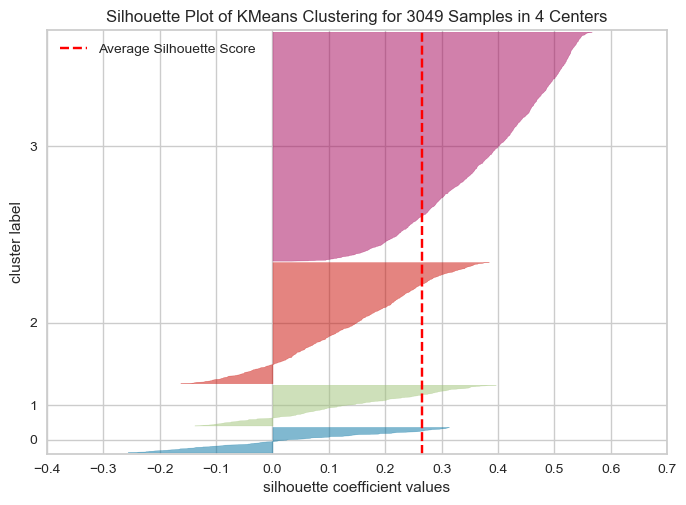

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 3049 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
visualizer = SilhouetteVisualizer(kmeans_final, colors='yellowbrick')
visualizer.fit(df_modificado.drop(columns=["item"]))  
visualizer.show()

### INTERPRETACIÓN DE LOS CLUSTERS

In [ ]:
# creamos un random forest para ver la importancia de las variables a la hora de predecir el cluster al que pertenece cada producto, y así entender mejor que características son las que definen cada cluster.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(df_modificado.drop(columns=["item"]), df_final["cluster_kmeans"])

NameError: name 'RandomForestClassifier' is not defined

In [ ]:
perm = permutation_importance(rf, X, y, n_repeats=10, random_state=42)
importancias_perm = pd.DataFrame({"variable": X.columns, "importance": perm.importances_mean}).sort_values("importance", ascending=False)
print(importancias_perm)

               variable  importance
1    precio medio total    0.164743
9             cv_ventas    0.142506
10  pct_dias_con_ventas    0.076156
4              Q3_total    0.036405
3              Q2_total    0.029616
5              Q4_total    0.028304
2              Q1_total    0.010790
0     unidades vendidas    0.003608
7   porcentaje_festivos    0.000722
11   elasticidad_precio    0.000262
6     porcentaje_findes    0.000000
8          regionalidad    0.000000


In [ ]:
# vemos un grafico para ver el tamaño de cada cluster
df = df_final["cluster_kmeans"].value_counts().sort_index().reset_index()
df.columns = ["cluster", "numero_productos"]
# convierto la columna cluster a string para que se vea mejor en el grafico
df["cluster"] = df["cluster"].astype(str)
fig = px.bar(df, x = "cluster", y = "numero_productos", title = "Número de productos por cluster", color = "cluster", text = "numero_productos")
fig.show()

In [ ]:
df_final

,item,unidades vendidas,precio medio total,Q1_total,Q2_total,Q3_total,Q4_total,porcentaje_findes,porcentaje_festivos,regionalidad,cv_ventas,pct_dias_con_ventas,elasticidad_precio,cluster_kmeans
0,ACCESORIES_1_001,4093,11.032746,0.284144,0.190569,0.232348,0.292939,0.332763,0.055949,0.493571,1.247697,0.508625,-1.222391,2
1,ACCESORIES_1_002,5059,5.276608,0.202807,0.192924,0.255584,0.348686,0.351255,0.042301,0.337518,0.885727,0.846315,NaN,3
2,ACCESORIES_1_003,1435,3.943978,0.294077,0.250174,0.221603,0.234146,0.379094,0.055749,0.283080,1.908945,0.312075,NaN,2
3,ACCESORIES_1_004,39175,5.982920,0.270989,0.257792,0.228156,0.243063,0.359872,0.047096,0.416094,0.401392,0.993204,NaN,3
4,ACCESORIES_1_005,14621,3.833668,0.238903,0.201423,0.253881,0.305793,0.359073,0.047466,0.315161,0.653834,0.922635,-0.720161,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,SUPERMARKET_3_823,15388,3.346839,0.290421,0.195347,0.249480,0.264752,0.348518,0.045100,0.522197,0.940970,0.730789,-1.231692,3
3045,SUPERMARKET_3_824,8325,3.026945,0.230390,0.322763,0.259580,0.187267,0.332492,0.038198,0.357495,0.906699,0.765813,-0.015322,0
3046,SUPERMARKET_3_825,13526,4.934360,0.304894,0.240869,0.259944,0.194292,0.347996,0.044877,0.191694,0.801660,0.806064,-0.317205,3
3047,SUPERMARKET_3_826,12188,1.535785,0.244585,0.295865,0.243764,0.215786,0.307269,0.039711,0.233635,1.015735,0.580763,NaN,3


In [ ]:
# ahora vamos a ver el perfil de cada cluster, es decir, la media de cada variable en cada cluster, y luego lo vamos a comparar con la mediana global de cada variable para ver en que se diferencian los clusters entre si y respecto al conjunto de datos en general.
variables = ['precio medio total', 'cv_ventas', 'pct_dias_con_ventas', 'unidades vendidas']
mediana_global = df_final[variables].median()
perfil_mediana = df_final.groupby("cluster_kmeans")[variables].median()
ratio_mediana = perfil_mediana.div(mediana_global, axis=1)
# print(ratio_mediana.round(2).T)

In [ ]:
fig = px.imshow(ratio_mediana.T, text_auto=".2f", color_continuous_scale="RdBu_r", aspect="auto", title="Perfil de los clusters (mediana de cada variable en cada cluster)")
fig.update_layout( xaxis_title="Cluster", yaxis_title="Variable")
fig.show()

In [ ]:
for col in variables:
    fig = px.box(df_final, x = "cluster_kmeans", y = col, title = f"Distribución de {col} por cluster", color = "cluster_kmeans")
    fig.show()

In [ ]:
mapa_clusters = {3: "Core", 2: "Esporádicos",  1: "Premium", 0: "Intermedios"}

In [ ]:
# para poder visualziar los clusters los pintamos en 3d con las 3 primeras componentes principales, que son las que explican la mayor parte de la variabilidad de los datos.
X = df_modificado.drop(columns=["item"]).copy()
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)
# creamos un dataframe con las componentes principales y la etiqueta del cluster para cada producto
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
df_pca["cluster"] = df_final["cluster_kmeans"].astype(str) # convertimos a string para que se vea mejor en el grafico
df_pca["item"] = df_final["item"]
df_pca["cluster_nombre"] = df_pca["cluster"].astype(int).map(mapa_clusters)
# ahora pintamos un grafico 3d con plotly
fig = px.scatter_3d(df_pca, x="PC1", y="PC2", z="PC3", color="cluster_nombre", title="Visualización de los clusters en 3D con las componentes principales", opacity = 0.5, hover_data=["item"],) # ponerle opacidad pq se ve fatal 
fig.update_traces(marker=dict(size=3)) # para que los puntos no sean tan grandes y se vea mejor la distribucion de los clusters
fig.show()   